## Machine Learning with Completed Simulations
Dan Chen, Summer 2026

### Imports

In [120]:
# === IMPORTS ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap, BoundaryNorm

from astropy import units as u
from pathlib import Path
from time import time
from collections import defaultdict
import seaborn as sns
import pickle as pkl

import mmr_id
import rebound_sims as reb_sims

import warnings
warnings.filterwarnings('ignore')
def plot_prettier(dpi=200, fontsize=8, usetex=False): 
    '''
    Make plots look nicer compared to Matplotlib defaults
    Parameters: 
        dpi - int, "dots per inch" - controls resolution of PNG images that are produced
                by Matplotlib
        fontsize - int, font size to use overall
        usetex - bool, whether to use LaTeX to render fonds of axes labels 
                use False if you don't have LaTeX installed on your system
    '''
    plt.rcParams['figure.dpi']= dpi
    plt.rc("savefig", dpi=dpi)
    plt.rc('font', size=fontsize)
    plt.rc('xtick', direction='in') 
    plt.rc('ytick', direction='in')
    plt.rc('xtick.major', pad=5) 
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=5) 
    plt.rc('ytick.minor', pad=5)
    plt.rc('lines', dotted_pattern = [2., 2.])
    if usetex:
        plt.rc('text', usetex=usetex)
    else:
        plt.rcParams['mathtext.fontset'] = 'cm'
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plot_prettier()

# === UNIT CONVERSIONS ===
AU = u.AU.to(u.cm)    
G = 4*np.pi**2 # in yr, AU, Msun
Msun = u.Msun.to(u.g) 
yr = u.yr.to(u.s)    
r_earth = u.earthRad.to(u.AU)
m_earth = u.Mearth.to(u.Msun)
r_sun = u.Rsun.to(u.AU) 

### Obtain stored outcome files

In [121]:
planet_outcomes = pd.read_hdf("dfs/planet_outcomes8_c.h5", key="df")

### Select planet survival or resonant outcomes

In [122]:
# Planet survival
classes = [1, 2, 3]
label = planet_outcomes["pl_survived"]
name = "Planets remaining"

# Inner/outer resonance class
classes = ["2:1", "3:2", "4:3", "5:4", "6:5", "7:6", "not in resonance", "other"][1:]
label = planet_outcomes["inner_res_class"]
name = "Resonance class"

### kNN

In [123]:
# Rescaling parameters
# # Use logspace for parameters
X_feat = pd.DataFrame({
    "logSigma": np.log10(planet_outcomes["Sigma_1au"]),
    "logh": np.log10(planet_outcomes["h_1au"])
})

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_ft_stand = scaler.fit_transform(X_feat)
# print(X_ft_stand.shape)

# for i in range(X_ft_stand.shape[1]):
#     print(X_ft_stand[:,i].min(), X_ft_stand[:,i].max())
    
# Splitting samples
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_ft_stand, label, train_size = 0.80, random_state = 42)

# === kNN ALGORITHM ===

from timeit import default_timer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

tstart = default_timer()
# define classifier object
knn = KNeighborsClassifier(n_neighbors=10, weights='distance')
# train classifier using the training data
knn.fit(X_train, y_train)

# predict classes for test data
ypred_knn = knn.predict(X_test)
print("Nearest neighbor classifier took %.2f sec"%(default_timer()-tstart))

# estimate classification accuracy of test data using correct answers for it
acc_knn = accuracy_score(y_test, ypred_knn)
print(f"nearest neighbors accuracy = {acc_knn:.3f}")

Nearest neighbor classifier took 0.00 sec
nearest neighbors accuracy = 0.815


#### Confusion matrix

In [124]:
from sklearn.metrics import confusion_matrix
import seaborn as sns # to plot the confusion matrix prettier

def conf_matrix(y_test, y_pred, class_names=None):
    """
    helper function computing confusion matrix
    """
    conf_mat = confusion_matrix(y_test, y_pred).T
    conf_mat = conf_mat.astype(float)

    # normalize confusion fraction
    for i in range(len(class_names)):
        conf_mat[i,:] /= float(np.sum(conf_mat[i,:]))

    return conf_mat

def plot_confusion_matrix(y_test, ypred, class_names = [1,2,3],
                          title=None, figsize=(3,3)):
    conf_mat = conf_matrix(y_test, ypred, class_names=class_names)

    plt.figure(figsize = figsize)
    if title is not None:
        plt.title(title, fontsize=10)
    sns.heatmap(conf_mat.T, square = True, annot=True, fmt='.3f', cmap='Blues', cbar=False,
               xticklabels= class_names,
               yticklabels= class_names)

    plt.xlabel('true')
    plt.ylabel('predicted')
    plt.show()

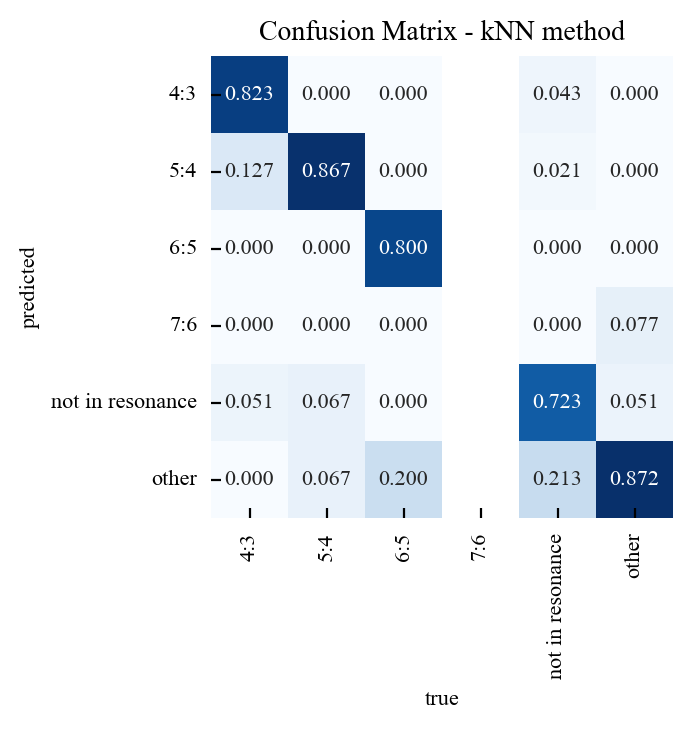

In [125]:
plot_confusion_matrix(y_test, ypred_knn, title='Confusion Matrix - kNN method', class_names=classes[1:])

#### Plot on parameter space

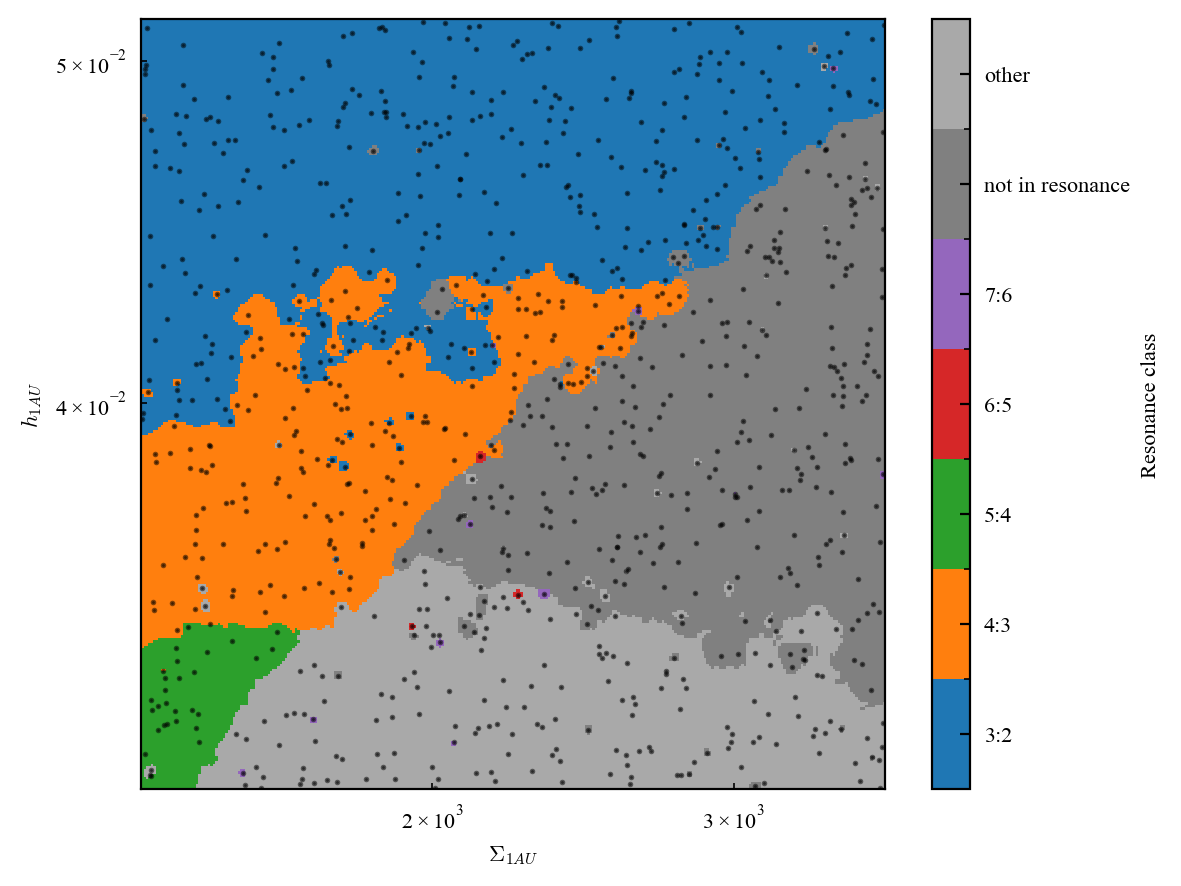

In [129]:
def plot_ml_pred(map_res=300):
    logSigma = np.linspace(
        np.log10(planet_outcomes["Sigma_1au"].min()),
        np.log10(planet_outcomes["Sigma_1au"].max()),
        map_res
    )

    logh = np.linspace(
        np.log10(planet_outcomes["h_1au"].min()),
        np.log10(planet_outcomes["h_1au"].max()),
        map_res
    )

    XX, YY = np.meshgrid(logSigma, logh)

    Xgrid = np.column_stack([
        XX.ravel(),
        YY.ravel()
    ])

    Xgrid_scaled = scaler.transform(Xgrid)

    Z = knn.predict(Xgrid_scaled)

    Z_int = np.array([classes.index(z) for z in Z], dtype=int)
    Z_int = Z_int.reshape(XX.shape)

    plt.figure(figsize=(6,5))

    cmap = ListedColormap(["C0", "C1", "C2", "C3", "C4", "gray", "darkgray"][:len(classes)])
    bounds = np.arange(len(classes) + 1) - 0.5
    norm = BoundaryNorm(bounds, cmap.N)

    mesh = plt.pcolormesh(
        10**XX,
        10**YY,
        Z_int,
        shading="auto",
        cmap=cmap,
        norm=norm
    )

    plt.scatter(
        planet_outcomes["Sigma_1au"],
        planet_outcomes["h_1au"],
        c="k",
        s=1,
        alpha=0.5
    )

    plt.xscale("log")
    plt.yscale("log")

    plt.xlabel(r"$\Sigma_{1AU}$")
    plt.ylabel(r"$h_{1AU}$")

    cbar = plt.colorbar(mesh, ticks=np.arange(len(classes)))
    cbar.set_ticklabels(classes)
    cbar.set_label(name)

    plt.show()
    
plot_ml_pred()

### ERF

In [127]:
from sklearn.ensemble import ExtraTreesClassifier

ert = ExtraTreesClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
)

ert.fit(X, y_inner)

Z_ert = ert.predict(Xgrid)
Z_ert = Z_ert.reshape(XX.shape)

plt.figure(figsize=(6,5))

plt.pcolormesh(
    10**XX,
    10**YY,
    Z_knn,
    shading="auto"
)

plt.scatter(
    planet_outcomes["Sigma_1au"],
    planet_outcomes["h_1au"],
    c='k',
    s=0.5,
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

cbar = plt.colorbar()
cbar.set_ticks(np.arange(len(encoder.classes_)))
cbar.set_ticklabels(encoder.classes_)

plt.show()

NameError: name 'X' is not defined